In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import pandas as pd

path = "/content/drive/MyDrive/"

# Load all files
matches = pd.read_csv(path + "PremierLeague.csv")
fixtures = pd.read_csv(path + "2024-2025 fixtures.csv")
fixtures_processed = pd.read_csv(path + "2024-2025 fixtures processed.csv")
team_match_stats = pd.read_csv(path + "team_match_stats.csv")
team_season_stats = pd.read_csv(path + "team_season_stats.csv")

# ⚠️ Update these with your actual Championship filenames
champ_2223 = pd.read_csv(path + "champ 2223.csv")
champ_2324 = pd.read_csv(path + "champ 2324.csv")

# Inspect all files
for name, df in {
    "PremierLeague": matches,
    "fixtures": fixtures,
    "fixtures_processed": fixtures_processed,
    "team_match_stats": team_match_stats,
    "team_season_stats": team_season_stats,
    "champ_2223": champ_2223,
    "champ_2324": champ_2324
}.items():
    print(f"\n{'='*40}")
    print(f"📄 {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(df.head(3))


📄 PremierLeague
Shape: (12160, 43)
Columns: ['MatchID', 'Season', 'MatchWeek', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FullTimeHomeTeamGoals', 'FullTimeAwayTeamGoals', 'FullTimeResult', 'HalfTimeHomeTeamGoals', 'HalfTimeAwayTeamGoals', 'HalfTimeResult', 'Referee', 'HomeTeamShots', 'AwayTeamShots', 'HomeTeamShotsOnTarget', 'AwayTeamShotsOnTarget', 'HomeTeamCorners', 'AwayTeamCorners', 'HomeTeamFouls', 'AwayTeamFouls', 'HomeTeamYellowCards', 'AwayTeamYellowCards', 'HomeTeamRedCards', 'AwayTeamRedCards', 'B365HomeTeam', 'B365Draw', 'B365AwayTeam', 'B365Over2.5Goals', 'B365Under2.5Goals', 'MarketMaxHomeTeam', 'MarketMaxDraw', 'MarketMaxAwayTeam', 'MarketAvgHomeTeam', 'MarketAvgDraw', 'MarketAvgAwayTeam', 'MarketMaxOver2.5Goals', 'MarketMaxUnder2.5Goals', 'MarketAvgOver2.5Goals', 'MarketAvgUnder2.5Goals', 'HomeTeamPoints', 'AwayTeamPoints']
                       MatchID     Season  MatchWeek        Date Time  \
0   1993-1994_Arsenal_Coventry  1993-1994          1  1993-08-14  NaN   
1   

In [41]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/"

# Load all files
matches = pd.read_csv(path + "PremierLeague.csv")
fixtures = pd.read_csv(path + "2024-2025 fixtures.csv")
fixtures_processed = pd.read_csv(path + "2024-2025 fixtures processed.csv")
team_match_stats = pd.read_csv(path + "team_match_stats.csv")
team_season_stats = pd.read_csv(path + "team_season_stats.csv")

# ⚠️ Update these with your actual Championship filenames
champ_2223 = pd.read_csv(path + "champ 2223.csv")
champ_2324 = pd.read_csv(path + "champ 2324.csv")

# ── Promoted teams this season (update if needed) ──
PROMOTED_TEAMS = ["Burnley", "Leeds", "Sunderland"]

name_map = {
    "Man Utd": "Man United",
    "Man City": "Man City",
    "Newcastle Utd": "Newcastle",
    "Nott'm Forest": "Nott'm Forest",
    "Wolves": "Wolves",
    "Wolverhampton": "Wolves",
    "Tottenham Hotspur": "Tottenham",
    "Leeds United": "Leeds",
    "Sheffield Weds": "Sheffield Wednesday",
}

def normalize(name):
    return name_map.get(str(name).strip(), str(name).strip())

In [42]:
# Filter last 2 full PL seasons
pl_recent = matches[matches['Season'].isin(['2023-2024', '2024-2025'])].copy()
pl_recent['HomeTeam'] = pl_recent['HomeTeam'].apply(normalize)
pl_recent['AwayTeam'] = pl_recent['AwayTeam'].apply(normalize)

def build_pl_team_stats(df):
    records = []
    for _, row in df.iterrows():
        # Home team
        records.append({
            'team': row['HomeTeam'], 'season': row['Season'],
            'GF': row['FullTimeHomeTeamGoals'], 'GA': row['FullTimeAwayTeamGoals'],
            'result': row['FullTimeResult'],  # H=win, D=draw, A=loss
            'points': row['HomeTeamPoints'], 'venue': 'Home'
        })
        # Away team
        records.append({
            'team': row['AwayTeam'], 'season': row['Season'],
            'GF': row['FullTimeAwayTeamGoals'], 'GA': row['FullTimeHomeTeamGoals'],
            'result': row['FullTimeResult'],
            'points': row['AwayTeamPoints'], 'venue': 'Away'
        })
    return pd.DataFrame(records)

pl_long = build_pl_team_stats(pl_recent)

# Map result to win/draw/loss from team perspective
def result_for_team(result, venue):
    if venue == 'Home':
        return 'W' if result == 'H' else ('D' if result == 'D' else 'L')
    else:
        return 'W' if result == 'A' else ('D' if result == 'D' else 'L')

pl_long['outcome'] = pl_long.apply(lambda r: result_for_team(r['result'], r['venue']), axis=1)

# Aggregate per team per season
pl_stats = pl_long.groupby(['team', 'season']).agg(
    games=('GF', 'count'),
    total_GF=('GF', 'sum'),
    total_GA=('GA', 'sum'),
    total_points=('points', 'sum'),
    wins=('outcome', lambda x: (x == 'W').sum()),
    draws=('outcome', lambda x: (x == 'D').sum()),
    losses=('outcome', lambda x: (x == 'L').sum()),
).reset_index()

pl_stats['avg_GF'] = pl_stats['total_GF'] / pl_stats['games']
pl_stats['avg_GA'] = pl_stats['total_GA'] / pl_stats['games']
pl_stats['ppg'] = pl_stats['total_points'] / pl_stats['games']
pl_stats['win_rate'] = pl_stats['wins'] / pl_stats['games']

print(pl_stats.head())

          team     season  games  total_GF  total_GA  total_points  wins  \
0      Arsenal  2023-2024     38        91        29            89    28   
1      Arsenal  2024-2025     38        69        34            74    20   
2  Aston Villa  2023-2024     38        76        61            68    20   
3  Aston Villa  2024-2025     38        58        51            66    19   
4  Bournemouth  2023-2024     38        54        67            48    13   

   draws  losses    avg_GF    avg_GA       ppg  win_rate  
0      5       5  2.394737  0.763158  2.342105  0.736842  
1     14       4  1.815789  0.894737  1.947368  0.526316  
2      8      10  2.000000  1.605263  1.789474  0.526316  
3      9      10  1.526316  1.342105  1.736842  0.500000  
4      9      16  1.421053  1.763158  1.263158  0.342105  


In [43]:
def build_champ_stats(df, season_label):
    df = df.copy()
    df['HomeTeam'] = df['HomeTeam'].apply(normalize)
    df['AwayTeam'] = df['AwayTeam'].apply(normalize)
    records = []
    for _, row in df.iterrows():
        records.append({
            'team': row['HomeTeam'], 'season': season_label,
            'GF': row['FTHG'], 'GA': row['FTAG'], 'result': row['FTR'], 'venue': 'Home'
        })
        records.append({
            'team': row['AwayTeam'], 'season': season_label,
            'GF': row['FTAG'], 'GA': row['FTHG'], 'result': row['FTR'], 'venue': 'Away'
        })
    long = pd.DataFrame(records)
    long['outcome'] = long.apply(lambda r: result_for_team(r['result'], r['venue']), axis=1)
    stats = long.groupby(['team', 'season']).agg(
        games=('GF', 'count'),
        total_GF=('GF', 'sum'),
        total_GA=('GA', 'sum'),
        wins=('outcome', lambda x: (x == 'W').sum()),
        draws=('outcome', lambda x: (x == 'D').sum()),
        losses=('outcome', lambda x: (x == 'L').sum()),
    ).reset_index()
    stats['avg_GF'] = stats['total_GF'] / stats['games']
    stats['avg_GA'] = stats['total_GA'] / stats['games']
    stats['win_rate'] = stats['wins'] / stats['games']
    # ── Division adjustment: Championship → PL drop-off ──
    stats['avg_GF'] = stats['avg_GF'] * 0.80
    stats['avg_GA'] = stats['avg_GA'] * 1.15
    stats['win_rate'] = stats['win_rate'] * 0.75
    stats['ppg'] = stats['win_rate'] * 3  # approximate
    return stats

champ_stats_2223 = build_champ_stats(champ_2223, '2022-2023')
champ_stats_2324 = build_champ_stats(champ_2324, '2023-2024')

# Keep only promoted teams
champ_promoted = pd.concat([champ_stats_2223, champ_stats_2324])
champ_promoted = champ_promoted[champ_promoted['team'].isin(PROMOTED_TEAMS)]

print(champ_promoted)

          team     season  games  total_GF  total_GA  wins  draws  losses  \
4      Burnley  2022-2023     46        87        35    29     14       3   
19  Sunderland  2022-2023     46        68        55    18     15      13   
8        Leeds  2023-2024     46        81        43    27      9      10   
20  Sunderland  2023-2024     46        52        54    16      8      22   

      avg_GF  avg_GA  win_rate       ppg  
4   1.513043   0.875  0.472826  1.418478  
19  1.182609   1.375  0.293478  0.880435  
8   1.408696   1.075  0.440217  1.320652  
20  0.904348   1.350  0.260870  0.782609  


In [44]:
pl_2526 = pd.read_csv(path + "premier_league_2526.csv")
pl_2526['HomeTeam'] = pl_2526['HomeTeam'].apply(normalize)
pl_2526['AwayTeam'] = pl_2526['AwayTeam'].apply(normalize)

# Build long format (one row per team per game)
records_2526 = []
for _, row in pl_2526.iterrows():
    # Home
    home_outcome = 'W' if row['FTR'] == 'H' else ('D' if row['FTR'] == 'D' else 'L')
    home_pts = 3 if home_outcome == 'W' else (1 if home_outcome == 'D' else 0)
    records_2526.append({
        'team': row['HomeTeam'], 'GF': row['FTHG'], 'GA': row['FTAG'],
        'outcome': home_outcome, 'points': home_pts, 'venue': 'Home', 'date': row['Date']
    })
    # Away
    away_outcome = 'W' if row['FTR'] == 'A' else ('D' if row['FTR'] == 'D' else 'L')
    away_pts = 3 if away_outcome == 'W' else (1 if away_outcome == 'D' else 0)
    records_2526.append({
        'team': row['AwayTeam'], 'GF': row['FTAG'], 'GA': row['FTHG'],
        'outcome': away_outcome, 'points': away_pts, 'venue': 'Away', 'date': row['Date']
    })

current_long = pd.DataFrame(records_2526)

# Aggregate current season stats
current_stats = current_long.groupby('team').agg(
    games=('GF', 'count'),
    GF=('GF', 'sum'),
    GA=('GA', 'sum'),
    wins=('outcome', lambda x: (x == 'W').sum()),
    draws=('outcome', lambda x: (x == 'D').sum()),
    losses=('outcome', lambda x: (x == 'L').sum()),
    current_points=('points', 'sum'),
).reset_index()

current_stats['avg_GF'] = current_stats['GF'] / current_stats['games']
current_stats['avg_GA'] = current_stats['GA'] / current_stats['games']
current_stats['ppg'] = current_stats['current_points'] / current_stats['games']
current_stats['win_rate'] = current_stats['wins'] / current_stats['games']
current_stats['GD'] = current_stats['GF'] - current_stats['GA']

print("\n📊 CURRENT 25/26 STANDINGS")
print("=" * 60)
print(current_stats[['team','games','current_points','GF','GA','GD','ppg']]
      .sort_values('current_points', ascending=False)
      .reset_index(drop=True)
      .to_string())


📊 CURRENT 25/26 STANDINGS
              team  games  current_points  GF  GA  GD       ppg
0          Arsenal     30              67  59  22  37  2.233333
1         Man City     29              60  59  27  32  2.068966
2       Man United     29              51  51  40  11  1.758621
3      Aston Villa     29              51  39  34   5  1.758621
4          Chelsea     29              48  53  34  19  1.655172
5        Liverpool     29              48  48  39   9  1.655172
6        Brentford     29              44  44  40   4  1.517241
7          Everton     29              43  34  33   1  1.482759
8      Bournemouth     29              40  44  46  -2  1.379310
9       Sunderland     29              40  30  34  -4  1.379310
10          Fulham     29              40  40  43  -3  1.379310
11       Newcastle     29              39  42  43  -1  1.344828
12  Crystal Palace     29              38  33  35  -2  1.310345
13        Brighton     29              37  38  36   2  1.275862
14           

In [45]:
# ── STEP 5: Merge All & Build Master Feature Table ──

# Step 5a: Average historical PL stats per team (last 2 seasons)
hist_avg = pl_stats.groupby('team').agg(
    hist_avg_GF=('avg_GF', 'mean'),
    hist_avg_GA=('avg_GA', 'mean'),
    hist_ppg=('ppg', 'mean'),
    hist_win_rate=('win_rate', 'mean'),
).reset_index()

# Step 5b: Championship averages for promoted teams
champ_avg = champ_promoted.groupby('team').agg(
    hist_avg_GF=('avg_GF', 'mean'),
    hist_avg_GA=('avg_GA', 'mean'),
    hist_ppg=('ppg', 'mean'),
    hist_win_rate=('win_rate', 'mean'),
).reset_index()

# Step 5c: Combine — PL history for established teams, Championship for promoted
hist_all = pd.concat([
    hist_avg[~hist_avg['team'].isin(PROMOTED_TEAMS)],
    champ_avg
]).reset_index(drop=True)

print("✅ hist_all teams:", sorted(hist_all['team'].tolist()))
print("✅ current_stats teams:", sorted(current_stats['team'].tolist()))

# Step 5d: Normalize team names before merging
hist_all['team'] = hist_all['team'].apply(normalize)
current_stats['team'] = current_stats['team'].apply(normalize)

# Step 5e: Merge current season with historical
master = current_stats.merge(hist_all, on='team', how='left')

# Step 5f: Flag any teams missing historical data
missing_hist = master[master['hist_ppg'].isna()]['team'].tolist()
if missing_hist:
    print(f"⚠️  Missing historical data for: {missing_hist}")
    print("    Filling with league average...")
    league_avg_GF = hist_avg['hist_avg_GF'].mean()
    league_avg_GA = hist_avg['hist_avg_GA'].mean()
    league_avg_ppg = hist_avg['hist_ppg'].mean()
    league_avg_wr = hist_avg['hist_win_rate'].mean()
    master['hist_avg_GF'] = master['hist_avg_GF'].fillna(league_avg_GF)
    master['hist_avg_GA'] = master['hist_avg_GA'].fillna(league_avg_GA)
    master['hist_ppg'] = master['hist_ppg'].fillna(league_avg_ppg)
    master['hist_win_rate'] = master['hist_win_rate'].fillna(league_avg_wr)

# Step 5g: Promoted team flag
master['is_promoted'] = master['team'].isin(PROMOTED_TEAMS).astype(int)

# Step 5h: Dynamic blend weight based on games played
games_played_avg = master['games'].mean()
CURRENT_WEIGHT = min(0.65, round(games_played_avg / 38, 2))
HIST_WEIGHT = round(1 - CURRENT_WEIGHT, 2)

print(f"\n⚖️  Blend weights → Current: {CURRENT_WEIGHT} | Historical: {HIST_WEIGHT}")
print(f"📅  Avg games played: {games_played_avg:.1f}")

# Step 5i: Blended ratings
master['blended_GF'] = (master['avg_GF'] * CURRENT_WEIGHT) + (master['hist_avg_GF'] * HIST_WEIGHT)
master['blended_GA'] = (master['avg_GA'] * CURRENT_WEIGHT) + (master['hist_avg_GA'] * HIST_WEIGHT)
master['blended_ppg'] = (master['ppg'] * CURRENT_WEIGHT) + (master['hist_ppg'] * HIST_WEIGHT)
master['blended_win_rate'] = (master['win_rate'] * CURRENT_WEIGHT) + (master['hist_win_rate'] * HIST_WEIGHT)

# Step 5j: Streak momentum bonus
# Sort each team's games by date and compute current streak
current_long['date'] = pd.to_datetime(current_long['date'], dayfirst=True)
current_long_sorted = current_long.sort_values(['team', 'date'])

def compute_streak(group):
    results = group['outcome'].tolist()
    if not results:
        return 0
    last = results[-1]
    streak = 0
    for r in reversed(results):
        if r == last:
            streak += 1
        else:
            break
    # Positive for win streak, negative for loss streak
    return streak if last == 'W' else (-streak if last == 'L' else 0)

streaks = current_long_sorted.groupby('team').apply(compute_streak).reset_index()
streaks.columns = ['team', 'streak']
streaks['team'] = streaks['team'].apply(normalize)

master = master.merge(streaks, on='team', how='left')
master['streak'] = master['streak'].fillna(0)

# Apply streak bonus: each game of win streak = +0.03 ppg, loss streak = -0.03 ppg
STREAK_FACTOR = 0.03
master['blended_ppg'] = master['blended_ppg'] + (master['streak'] * STREAK_FACTOR)
master['blended_ppg'] = master['blended_ppg'].clip(0, 3)  # cap between 0 and 3

print("\n📋 MASTER TABLE PREVIEW")
print("=" * 75)
print(master[['team','games','current_points','ppg','hist_ppg','blended_ppg','streak','is_promoted']]
      .sort_values('current_points', ascending=False)
      .reset_index(drop=True)
      .to_string())

✅ hist_all teams: ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Sheffield United', 'Southampton', 'Sunderland', 'Tottenham', 'West Ham', 'Wolves']
✅ current_stats teams: ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Sunderland', 'Tottenham', 'West Ham', 'Wolves']

⚖️  Blend weights → Current: 0.65 | Historical: 0.35
📅  Avg games played: 29.1

📋 MASTER TABLE PREVIEW
              team  games  current_points       ppg  hist_ppg  blended_ppg  streak  is_promoted
0          Arsenal     30              67  2.233333  2.144737     2.292325       3            0
1         Man City     29              60  2.068966  2.131579     2.090880       0   

/tmp/ipykernel_467/2202312834.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  streaks = current_long_sorted.groupby('team').apply(compute_streak).reset_index()


In [46]:
# 38 total games per team, 3 played, 35 remaining
# Each match appears twice in current_long (home + away team)
# So divide by 2 to get actual matchweeks played
total_team_games = len(pl_2526)  # number of actual matches played
games_played_actual = round(total_team_games / 10)  # 20 teams, 10 matches per matchweek
games_remaining = 38 - games_played_actual

print(f"📅 Matches played: {total_team_games}")
print(f"📅 Matchweeks completed: {games_played_actual}")
print(f"📅 Games remaining: {games_remaining}")

TOTAL_GAMES = 38 # Define TOTAL_GAMES as 38 (total games in a PL season)
master['projected_points'] = master['current_points'] + (master['blended_ppg'] * games_remaining)
master['projected_GD'] = (master['blended_GF'] - master['blended_GA']) * TOTAL_GAMES

# Final predicted table
predicted_table = master[['team','current_points','projected_points','blended_GF','blended_GA','projected_GD','is_promoted']]\
    .sort_values(['projected_points','projected_GD'], ascending=False)\
    .reset_index(drop=True)

predicted_table.index += 1  # start at 1
predicted_table.index.name = 'Predicted Position'

print("\n🏆 PREDICTED PREMIER LEAGUE TABLE 2025/26")
print("=" * 65)
print(predicted_table.to_string())

📅 Matches played: 291
📅 Matchweeks completed: 29
📅 Games remaining: 9

🏆 PREDICTED PREMIER LEAGUE TABLE 2025/26
                              team  current_points  projected_points  blended_GF  blended_GA  projected_GD  is_promoted
Predicted Position                                                                                                     
1                          Arsenal              67         87.630921    2.015175    0.766798     47.438333            0
2                         Man City              60         78.817922    2.096098    0.964383     43.005172            0
3                      Aston Villa              51         66.301878    1.491243    1.277858      8.108621            0
4                       Man United              51         65.245563    1.608235    1.412341      7.443966            0
5                        Liverpool              48         64.293022    1.867967    1.251770     23.415517            0
6                          Chelsea              

In [47]:
# Check what fixtures file has for 25/26 remaining games
print("=== FIXTURES FILE ===")
print(fixtures.columns.tolist())
print(fixtures.head(5))

# Also check fixtures_processed
print("\n=== FIXTURES PROCESSED ===")
print(fixtures_processed.columns.tolist())
print(fixtures_processed.head(5))

# Check date range in pl_2526 to know last matchweek played
pl_2526['Date'] = pd.to_datetime(pl_2526['Date'], dayfirst=True)
print(f"\n📅 First game in pl_2526: {pl_2526['Date'].min()}")
print(f"📅 Last game in pl_2526: {pl_2526['Date'].max()}")
print(f"📅 Total matches played: {len(pl_2526)}")

=== FIXTURES FILE ===
['Match Number', 'Round Number', 'Date', 'Location', 'Home Team', 'Away Team', 'Result']
   Match Number  Round Number              Date          Location  Home Team  \
0             1             1  16/08/2024 20:00      Old Trafford    Man Utd   
1             2             1  17/08/2024 12:30      Portman Road    Ipswich   
2             3             1  17/08/2024 15:00  Emirates Stadium    Arsenal   
3             4             1  17/08/2024 15:00     Goodison Park    Everton   
4             5             1  17/08/2024 15:00   St. James' Park  Newcastle   

     Away Team Result  
0       Fulham  1 - 0  
1    Liverpool  0 - 2  
2       Wolves  2 - 0  
3     Brighton  0 - 3  
4  Southampton  1 - 0  

=== FIXTURES PROCESSED ===
['MatchID', 'Round Number', 'Date']
                           MatchID  Round Number              Date
0      2024-2025_Man United_Fulham             1  16/08/2024 20:00
1      2024-2025_Ipswich_Liverpool             1  17/08/2024 12:30

In [48]:
# ── Step 7a: Figure out which fixtures are left ──
# 38 matchweeks × 10 games = 380 total games
# 291 played, so 89 remaining... but we said 9 matchweeks
# Let's verify matchweeks played

pl_2526['matchweek'] = pl_2526.groupby('Date').ngroup()
print(f"Distinct matchdays in pl_2526: {pl_2526['Date'].nunique()}")
print(f"Games per matchday sample:\n{pl_2526.groupby('Date').size().tail(10)}")

Distinct matchdays in pl_2526: 83
Games per matchday sample:
Date
2026-02-18    1
2026-02-21    5
2026-02-22    4
2026-02-23    1
2026-02-27    1
2026-02-28    5
2026-03-01    4
2026-03-03    4
2026-03-04    5
2026-03-05    1
dtype: int64


In [49]:
# ── STEP 7: Remaining Fixtures & Poisson Match Predictor ──

import scipy.stats as stats
import itertools

# ── Step 7a: All remaining fixtures (Matchweeks 30-38) ──
remaining_fixtures = [
    # Matchweek 30
    ("Arsenal", "Bournemouth"), ("Brentford", "Everton"),
    ("Burnley", "Brighton"), ("Crystal Palace", "Newcastle"),
    ("Nottm Forest", "Aston Villa"), ("Liverpool", "Fulham"),
    ("Sunderland", "Tottenham"), ("Chelsea", "Man City"),
    ("Man United", "Leeds"), ("Wolves", "West Ham"),

    # Matchweek 31
    ("Bournemouth", "Sunderland"), ("Aston Villa", "Burnley"),
    ("Brighton", "Crystal Palace"), ("Everton", "Chelsea"),
    ("Fulham", "Wolves"), ("Leeds", "Liverpool"),
    ("Man City", "Brentford"), ("Newcastle", "Man United"),
    ("Tottenham", "Arsenal"), ("West Ham", "Nottm Forest"),

    # Matchweek 32
    ("Arsenal", "Everton"), ("Brentford", "Fulham"),
    ("Burnley", "Nottm Forest"), ("Chelsea", "Newcastle"),
    ("Crystal Palace", "Leeds"), ("Liverpool", "Tottenham"),
    ("Man United", "Brighton"), ("Sunderland", "Wolves"),
    ("Aston Villa", "West Ham"), ("Bournemouth", "Man City"),

    # Matchweek 33
    ("Brighton", "Sunderland"), ("Everton", "Man City"),
    ("Fulham", "Arsenal"), ("Leeds", "Brentford"),
    ("Man United", "Chelsea"), ("Newcastle", "Liverpool"),
    ("Nottm Forest", "Crystal Palace"), ("Tottenham", "Burnley"),
    ("West Ham", "Bournemouth"), ("Wolves", "Aston Villa"),

    # Matchweek 34
    ("Arsenal", "Man City"), ("Aston Villa", "Leeds"),
    ("Bournemouth", "Newcastle"), ("Brentford", "West Ham"),
    ("Burnley", "Wolves"), ("Chelsea", "Liverpool"),
    ("Crystal Palace", "Everton"), ("Fulham", "Tottenham"),
    ("Man United", "Nottm Forest"), ("Sunderland", "Brighton"),

    # Matchweek 35
    ("Brighton", "Wolves"), ("Everton", "Burnley"),
    ("Leeds", "Crystal Palace"), ("Liverpool", "Chelsea"),
    ("Man City", "Man United"), ("Newcastle", "Sunderland"),
    ("Nottm Forest", "Fulham"), ("Tottenham", "Brentford"),
    ("West Ham", "Arsenal"), ("Aston Villa", "Bournemouth"),

    # Matchweek 36
    ("Arsenal", "Newcastle"), ("Bournemouth", "Chelsea"),
    ("Brentford", "Brighton"), ("Burnley", "Everton"),
    ("Crystal Palace", "Man City"), ("Fulham", "Leeds"),
    ("Man United", "Aston Villa"), ("Sunderland", "Liverpool"),
    ("Wolves", "Tottenham"), ("Nottm Forest", "West Ham"),

    # Matchweek 37
    ("Arsenal", "Burnley"), ("Aston Villa", "Crystal Palace"),
    ("Brighton", "Man United"), ("Chelsea", "Brentford"),
    ("Everton", "Sunderland"), ("Leeds", "West Ham"),
    ("Liverpool", "Man City"), ("Newcastle", "Fulham"),
    ("Tottenham", "Wolves"), ("Bournemouth", "Nottm Forest"),

    # Matchweek 38
    ("Arsenal", "Crystal Palace"), ("Aston Villa", "Man United"),
    ("Brentford", "Burnley"), ("Brighton", "Newcastle"),
    ("Chelsea", "Wolves"), ("Everton", "Liverpool"),
    ("Fulham", "Man City"), ("Leeds", "Tottenham"),
    ("Nottm Forest", "Sunderland"), ("West Ham", "Bournemouth"),
]

remaining_df = pd.DataFrame(remaining_fixtures, columns=['HomeTeam', 'AwayTeam'])
print(f"Total remaining fixtures: {len(remaining_df)}")

# ── Step 7b: Build attack & defense strength ratings ──
# League averages from current season
league_avg_scored = current_stats['avg_GF'].mean()
league_avg_conceded = current_stats['avg_GA'].mean()

# Home advantage factor
home_games = current_long[current_long['venue'] == 'Home']
away_games = current_long[current_long['venue'] == 'Away']
home_avg_goals = home_games['GF'].mean()
away_avg_goals = away_games['GF'].mean()
home_advantage = home_avg_goals / away_avg_goals
print(f"\n🏠 Home advantage factor: {home_advantage:.3f}")
print(f"⚽ League avg scored: {league_avg_scored:.3f} | conceded: {league_avg_conceded:.3f}")

# Per team: attack strength = team avg GF / league avg GF
#           defense strength = team avg GA / league avg GA
strength = current_stats[['team', 'avg_GF', 'avg_GA']].copy()
strength['attack']  = strength['avg_GF'] / league_avg_scored
strength['defense'] = strength['avg_GA'] / league_avg_conceded
strength = strength.set_index('team')

print("\n📊 Team Strengths (attack / defense — higher defense = worse):")
print(strength[['attack','defense']].round(3).sort_values('attack', ascending=False).to_string())

# ── Step 7c: Poisson predictor ──
def predict_match(home, away, strength, home_advantage, league_avg):
    try:
        home_exp = strength.loc[home, 'attack'] * strength.loc[away, 'defense'] * league_avg * home_advantage
        away_exp = strength.loc[away, 'attack'] * strength.loc[home, 'defense'] * league_avg
    except KeyError as e:
        print(f"⚠️ Missing team: {e}")
        return None

    home_win, draw, away_win = 0, 0, 0
    scoreline_probs = {}

    for hg in range(8):
        for ag in range(8):
            p = stats.poisson.pmf(hg, home_exp) * stats.poisson.pmf(ag, away_exp)
            scoreline_probs[(hg, ag)] = p
            if hg > ag:   home_win += p
            elif hg == ag: draw    += p
            else:          away_win += p

    # Most likely scoreline
    best_score = max(scoreline_probs, key=scoreline_probs.get)

    return {
        'home_exp': round(home_exp, 2),
        'away_exp': round(away_exp, 2),
        'home_win': round(home_win, 3),
        'draw':     round(draw, 3),
        'away_win': round(away_win, 3),
        'pred_home_goals': best_score[0],
        'pred_away_goals': best_score[1],
    }

# ── Step 7d: Run predictions for all remaining games ──
results = []
for _, row in remaining_df.iterrows():
    home, away = row['HomeTeam'], row['AwayTeam']
    pred = predict_match(home, away, strength, home_advantage, league_avg_scored)
    if pred:
        results.append({
            'HomeTeam': home, 'AwayTeam': away,
            **pred
        })

predictions_df = pd.DataFrame(results)
print(f"\n✅ Predictions generated: {len(predictions_df)}")
print(predictions_df[['HomeTeam','AwayTeam','pred_home_goals','pred_away_goals','home_win','draw','away_win']].head(20).to_string())

# ── Step 7e: Simulate final table from predictions ──
# Start from current points
final_table = current_stats.set_index('team')[['current_points', 'GF', 'GA', 'GD']].copy()
final_table.columns = ['points', 'GF', 'GA', 'GD']

for _, row in predictions_df.iterrows():
    home, away = row['HomeTeam'], row['AwayTeam']
    hg, ag = row['pred_home_goals'], row['pred_away_goals']

    # Update goals
    if home in final_table.index:
        final_table.loc[home, 'GF'] += hg
        final_table.loc[home, 'GA'] += ag
        final_table.loc[home, 'GD'] += (hg - ag)
    if away in final_table.index:
        final_table.loc[away, 'GF'] += ag
        final_table.loc[away, 'GA'] += hg
        final_table.loc[away, 'GD'] += (ag - hg)

    # Update points
    if hg > ag:
        if home in final_table.index: final_table.loc[home, 'points'] += 3
    elif hg == ag:
        if home in final_table.index: final_table.loc[home, 'points'] += 1
        if away in final_table.index: final_table.loc[away, 'points'] += 1
    else:
        if away in final_table.index: final_table.loc[away, 'points'] += 3

# ── Step 7f: Print final predicted table ──
final_table = final_table.sort_values(['points', 'GD'], ascending=False).reset_index()
final_table.index += 1
final_table.index.name = 'Position'

def get_zone(pos):
    if pos <= 4:   return '🏆 Champions League'
    elif pos <= 6: return '🟠 Europa League'
    elif pos == 7: return '🟡 Conference League'
    elif pos >= 18: return '🔴 Relegation'
    else:           return ''

final_table['Zone'] = final_table.index.map(get_zone)
final_table['points'] = final_table['points'].astype(int)
final_table['GD'] = final_table['GD'].round(1)

print("\n🏆 PREDICTED FINAL TABLE — 2025/26 PREMIER LEAGUE (Poisson Model)")
print("=" * 70)
print(final_table[['team','points','GF','GA','GD','Zone']].to_string())

Total remaining fixtures: 90

🏠 Home advantage factor: 1.205
⚽ League avg scored: 1.387 | conceded: 1.387

📊 Team Strengths (attack / defense — higher defense = worse):
                attack  defense
team                           
Man City         1.467    0.671
Arsenal          1.418    0.529
Chelsea          1.318    0.845
Man United       1.268    0.994
Liverpool        1.194    0.970
Bournemouth      1.094    1.144
Brentford        1.094    0.994
Newcastle        1.044    1.069
Fulham           0.995    1.069
Aston Villa      0.970    0.845
Tottenham        0.970    1.144
Brighton         0.945    0.895
Leeds            0.920    1.193
West Ham         0.870    1.342
Everton          0.845    0.820
Crystal Palace   0.821    0.870
Burnley          0.796    1.442
Sunderland       0.746    0.845
Nott'm Forest    0.696    1.069
Wolves           0.529    1.250
⚠️ Missing team: 'Nottm Forest'
⚠️ Missing team: 'Nottm Forest'
⚠️ Missing team: 'Nottm Forest'
⚠️ Missing team: 'Nottm Forest'

/tmp/ipykernel_467/3231398658.py:78: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/3231398658.py:78: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/3231398658.py:78: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/3231398658.py:78: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/3231398658.py:79: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/pl_predicted_table.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_467/3231398658.py:79: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/drive/MyDrive/pl_predicted_table.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_467/32

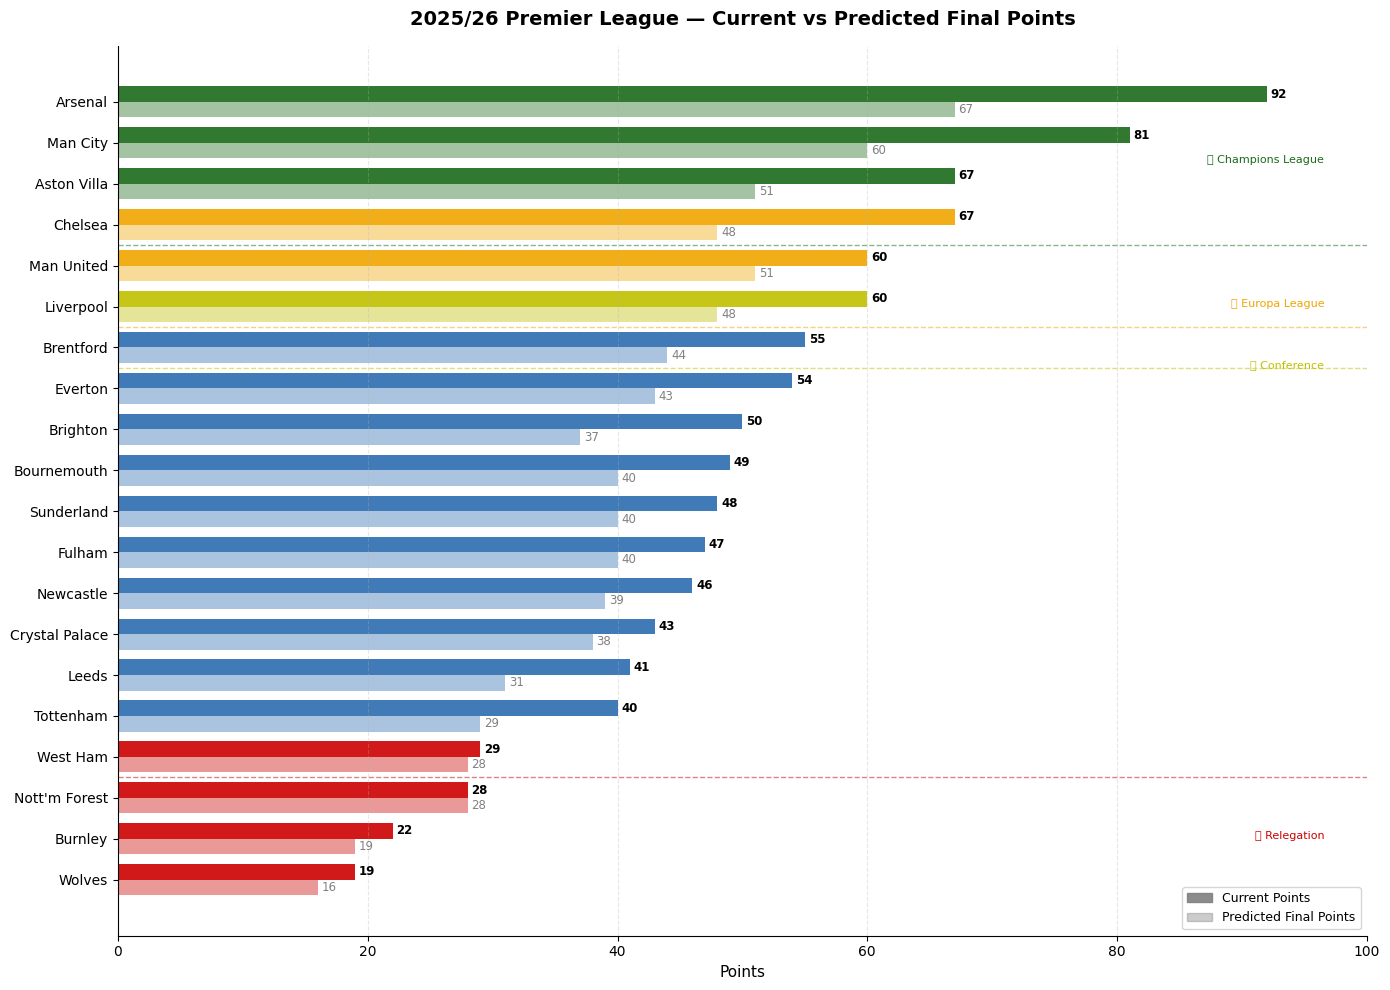

✅ Saved to Google Drive as pl_predicted_table.png


In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data prep ──
viz_df = final_table[['team', 'points']].copy()
viz_df = viz_df.rename(columns={'points': 'predicted_points'})
viz_df = viz_df.merge(current_stats[['team', 'current_points']], on='team')
viz_df = viz_df.sort_values('predicted_points', ascending=True).reset_index(drop=True)

# ── Zone colors ──
def get_zone_color(pos, total=20):
    rank = total - pos  # since sorted ascending
    if rank <= 3:   return '#1a6b1a'   # top 4 — dark green
    elif rank <= 5: return '#f0a500'   # europa — orange
    elif rank == 6: return '#c0c000'   # conference — yellow
    elif rank >= 17: return '#cc0000'  # relegation — red
    else:           return '#2b6cb0'   # mid table — blue

colors = [get_zone_color(i) for i in range(len(viz_df))]

# ── Plot ──
fig, ax = plt.subplots(figsize=(14, 10))
y = np.arange(len(viz_df))
bar_height = 0.38

# Predicted points bars
bars1 = ax.barh(y + bar_height/2, viz_df['predicted_points'], bar_height,
                color=colors, alpha=0.9, label='Predicted Final Points')

# Current points bars (lighter shade)
bars2 = ax.barh(y - bar_height/2, viz_df['current_points'], bar_height,
                color=colors, alpha=0.4, label='Current Points')

# Value labels
for i, (pred, curr) in enumerate(zip(viz_df['predicted_points'], viz_df['current_points'])):
    ax.text(pred + 0.3, i + bar_height/2, str(int(pred)),
            va='center', fontsize=8.5, fontweight='bold')
    ax.text(curr + 0.3, i - bar_height/2, str(int(curr)),
            va='center', fontsize=8.5, color='gray')

# Team labels
ax.set_yticks(y)
ax.set_yticklabels(viz_df['team'], fontsize=10)

# Zone divider lines
ax.axhline(y=19 - 3.5, color='#1a6b1a', linestyle='--', linewidth=1, alpha=0.5)  # CL cutoff
ax.axhline(y=19 - 5.5, color='#f0a500', linestyle='--', linewidth=1, alpha=0.5)  # EL cutoff
ax.axhline(y=19 - 6.5, color='#c0c000', linestyle='--', linewidth=1, alpha=0.5)  # Conference cutoff
ax.axhline(y=2.5,       color='#cc0000', linestyle='--', linewidth=1, alpha=0.5)  # Relegation cutoff

# Zone labels on right
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 90, 19 - 1.5,
        '🏆 Champions League', fontsize=8, color='#1a6b1a', ha='right')
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 90, 19 - 5,
        '🟠 Europa League', fontsize=8, color='#f0a500', ha='right')
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 90, 19 - 6.5,
        '🟡 Conference', fontsize=8, color='#c0c000', ha='right')
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 90, 1,
        '🔴 Relegation', fontsize=8, color='#cc0000', ha='right')

# Legend
legend_patches = [
    mpatches.Patch(color='gray', alpha=0.9, label='Current Points'),
    mpatches.Patch(color='gray', alpha=0.4, label='Predicted Final Points'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

# Styling
ax.set_xlabel('Points', fontsize=11)
ax.set_title('2025/26 Premier League — Current vs Predicted Final Points',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, max(viz_df['predicted_points']) + 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pl_predicted_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to Google Drive as pl_predicted_table.png")

First half games:  188
Second half games: 192

🎯 Method 2 Outcome Accuracy: 53.6%

📋 METHOD 2 — Predicted vs Actual 23/24
Pred Pos  Team                  Pred Pts    Actual Pts  Actual Pos  Pos Error
----------------------------------------------------------------------
1         Liverpool             93          82          3           2
2         Man City              93          91          1           1
3         Aston Villa           85          68          4           1
4         Arsenal               83          89          2           2
5         Tottenham             73          66          5           0
6         Newcastle             67          60          7           1
7         Brighton              66          48          11          4
8         West Ham              61          52          9           1
9         Chelsea               50          63          6           3
10        Man United            49          60          8           2
11        Everton            

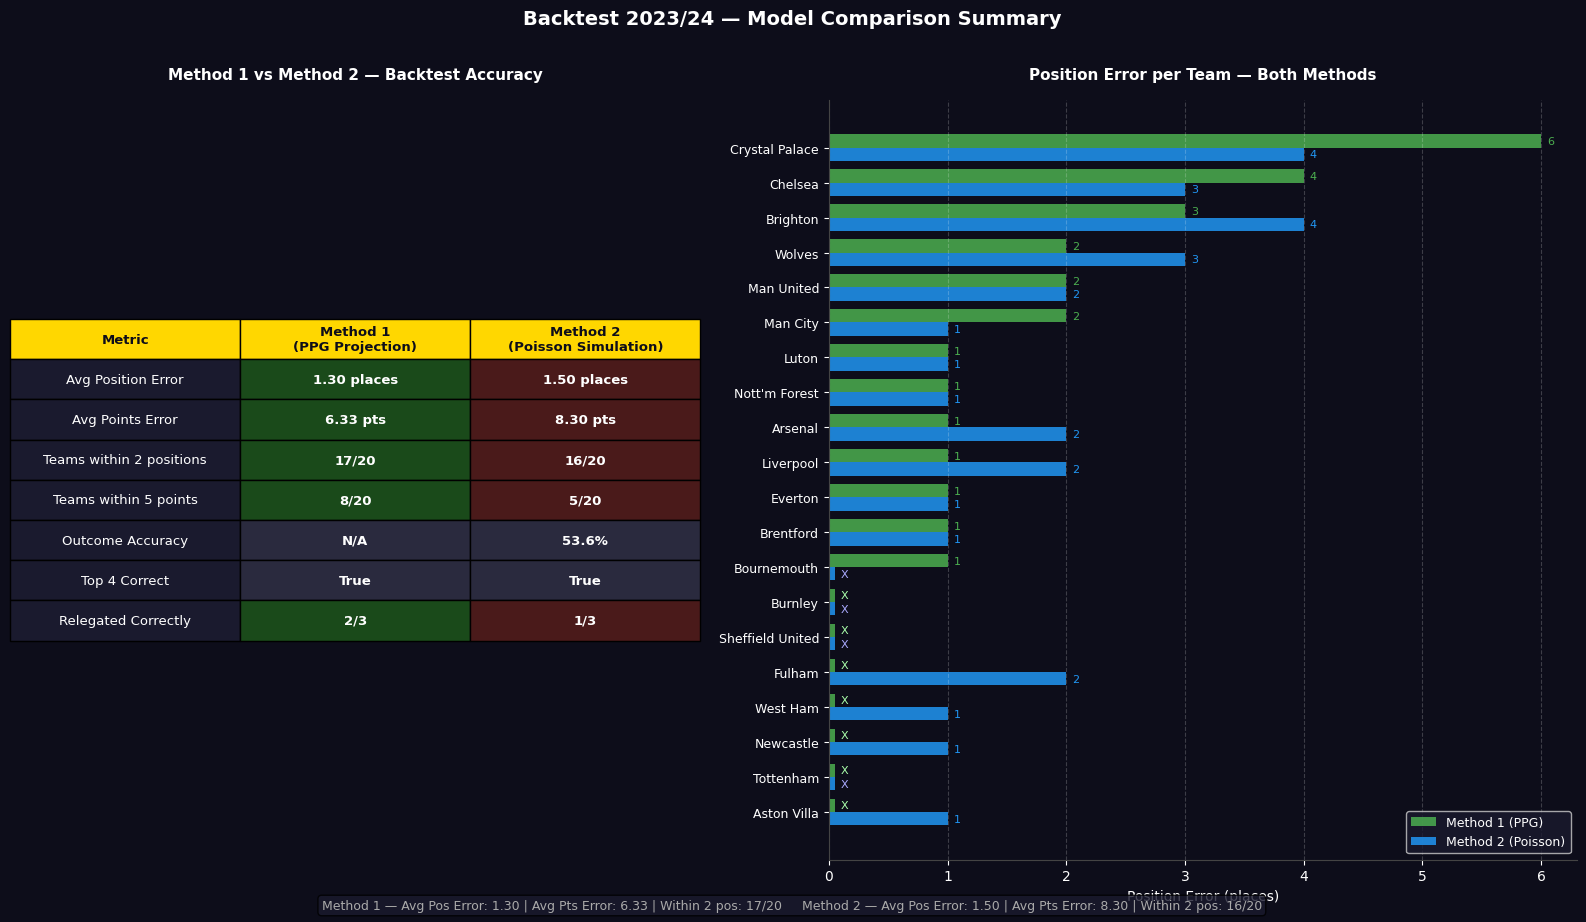

✅ Saved to Google Drive as pl_backtest_method_comparison.png


In [51]:
# ════════════════════════════════════════════════════════════
# BACKTEST: Train on 23/24 first half, predict second half
# ════════════════════════════════════════════════════════════

import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Step A: Split 23/24 into first half and second half ──
pl_2324 = matches[matches['Season'] == '2023-2024'].copy()
pl_2324['HomeTeam'] = pl_2324['HomeTeam'].apply(normalize)
pl_2324['AwayTeam'] = pl_2324['AwayTeam'].apply(normalize)

first_half  = pl_2324[pl_2324['MatchWeek'] <= 19]
second_half = pl_2324[pl_2324['MatchWeek'] > 19]

print(f"First half games:  {len(first_half)}")
print(f"Second half games: {len(second_half)}")

# ── Step B: Build team stats from first half ──
def build_stats_from_pl(df):
    records = []
    for _, row in df.iterrows():
        home_outcome = 'W' if row['FullTimeResult'] == 'H' else ('D' if row['FullTimeResult'] == 'D' else 'L')
        away_outcome = 'W' if row['FullTimeResult'] == 'A' else ('D' if row['FullTimeResult'] == 'D' else 'L')
        records.append({
            'team': row['HomeTeam'], 'GF': row['FullTimeHomeTeamGoals'],
            'GA': row['FullTimeAwayTeamGoals'], 'outcome': home_outcome,
            'points': 3 if home_outcome == 'W' else (1 if home_outcome == 'D' else 0),
            'venue': 'Home'
        })
        records.append({
            'team': row['AwayTeam'], 'GF': row['FullTimeAwayTeamGoals'],
            'GA': row['FullTimeHomeTeamGoals'], 'outcome': away_outcome,
            'points': 3 if away_outcome == 'W' else (1 if away_outcome == 'D' else 0),
            'venue': 'Away'
        })
    long  = pd.DataFrame(records)
    stats_df = long.groupby('team').agg(
        games=('GF', 'count'),
        GF=('GF', 'sum'), GA=('GA', 'sum'),
        current_points=('points', 'sum'),
        wins=('outcome',   lambda x: (x == 'W').sum()),
        draws=('outcome',  lambda x: (x == 'D').sum()),
        losses=('outcome', lambda x: (x == 'L').sum()),
    ).reset_index()
    stats_df['avg_GF']    = stats_df['GF'] / stats_df['games']
    stats_df['avg_GA']    = stats_df['GA'] / stats_df['games']
    stats_df['GD']        = stats_df['GF'] - stats_df['GA']
    stats_df['ppg']       = stats_df['current_points'] / stats_df['games']
    stats_df['win_rate']  = stats_df['wins'] / stats_df['games']
    return stats_df, long

first_half_stats, first_half_long = build_stats_from_pl(first_half)

# ── Step C: Poisson strength ratings from first half ──
league_avg_scored_bt = first_half_stats['avg_GF'].mean()
home_games_bt        = first_half_long[first_half_long['venue'] == 'Home']
away_games_bt        = first_half_long[first_half_long['venue'] == 'Away']
home_adv_bt          = home_games_bt['GF'].mean() / away_games_bt['GF'].mean()

strength_bt = first_half_stats[['team', 'avg_GF', 'avg_GA']].copy()
strength_bt['attack']  = strength_bt['avg_GF'] / league_avg_scored_bt
strength_bt['defense'] = strength_bt['avg_GA'] / league_avg_scored_bt
strength_bt = strength_bt.set_index('team')

# ── Step D: Predict all second half fixtures (Method 2 — Poisson) ──
second_half_fixtures = second_half[['HomeTeam', 'AwayTeam',
                                    'FullTimeHomeTeamGoals',
                                    'FullTimeAwayTeamGoals']].copy()

def get_outcome(hg, ag):
    return 'H' if hg > ag else ('D' if hg == ag else 'A')

predicted_results = []
for _, row in second_half_fixtures.iterrows():
    home, away = row['HomeTeam'], row['AwayTeam']
    pred = predict_match(home, away, strength_bt, home_adv_bt, league_avg_scored_bt)
    if pred:
        predicted_results.append({
            'HomeTeam': home, 'AwayTeam': away,
            'pred_home':   pred['pred_home_goals'],
            'pred_away':   pred['pred_away_goals'],
            'actual_home': row['FullTimeHomeTeamGoals'],
            'actual_away': row['FullTimeAwayTeamGoals'],
        })

pred_df = pd.DataFrame(predicted_results)

# ── Step E: Outcome accuracy (Method 2) ──
pred_df['pred_result']   = pred_df.apply(lambda r: get_outcome(r['pred_home'],   r['pred_away']),   axis=1)
pred_df['actual_result'] = pred_df.apply(lambda r: get_outcome(r['actual_home'], r['actual_away']), axis=1)
pred_df['correct']       = pred_df['pred_result'] == pred_df['actual_result']
outcome_accuracy         = pred_df['correct'].mean() * 100

print(f"\n🎯 Method 2 Outcome Accuracy: {outcome_accuracy:.1f}%")

# ── Step F: Build Method 2 predicted final table ──
backtest_table = first_half_stats.set_index('team')[['current_points', 'GF', 'GA', 'GD']].copy()
backtest_table.columns = ['points', 'GF', 'GA', 'GD']

for _, row in pred_df.iterrows():
    home, away = row['HomeTeam'], row['AwayTeam']
    hg, ag     = row['pred_home'], row['pred_away']
    if home in backtest_table.index:
        backtest_table.loc[home, 'GF'] += hg
        backtest_table.loc[home, 'GA'] += ag
        backtest_table.loc[home, 'GD'] += (hg - ag)
    if away in backtest_table.index:
        backtest_table.loc[away, 'GF'] += ag
        backtest_table.loc[away, 'GA'] += hg
        backtest_table.loc[away, 'GD'] += (ag - hg)
    if hg > ag:
        if home in backtest_table.index: backtest_table.loc[home, 'points'] += 3
    elif hg == ag:
        if home in backtest_table.index: backtest_table.loc[home, 'points'] += 1
        if away in backtest_table.index: backtest_table.loc[away, 'points'] += 1
    else:
        if away in backtest_table.index: backtest_table.loc[away, 'points'] += 3

predicted_final = backtest_table.sort_values(['points', 'GD'], ascending=False).reset_index()
predicted_final.index += 1
predicted_final.index.name = 'Predicted Pos'

# ── Step G: Actual 23/24 final table ──
actual_stats, _  = build_stats_from_pl(pl_2324)
actual_final     = actual_stats.sort_values(['current_points', 'GD'], ascending=False).reset_index()
actual_final.index += 1
actual_final.index.name = 'Actual Pos'

actual_lookup     = actual_final[['team', 'current_points']].rename(columns={'current_points': 'actual_points'})
actual_pos_lookup = actual_final.reset_index()[['Actual Pos', 'team']].rename(columns={'Actual Pos': 'actual_pos'})
actual_lookup2    = actual_lookup.merge(actual_pos_lookup, on='team')

# ── Step H: Method 2 comparison ──
m2_comparison = predicted_final[['team', 'points']].copy()
m2_comparison.columns = ['team', 'predicted_points']
m2_comparison['predicted_pos'] = range(1, len(m2_comparison) + 1)
m2_comparison = m2_comparison.merge(actual_lookup2, on='team')
m2_comparison['pos_error']    = abs(m2_comparison['predicted_pos'] - m2_comparison['actual_pos'])
m2_comparison['points_error'] = abs(m2_comparison['predicted_points'] - m2_comparison['actual_points'])

avg_pos_error = m2_comparison['pos_error'].mean()
avg_pts_error = m2_comparison['points_error'].mean()

print(f"\n📋 METHOD 2 — Predicted vs Actual 23/24")
print("=" * 70)
print(f"{'Pred Pos':<10}{'Team':<22}{'Pred Pts':<12}{'Actual Pts':<12}{'Actual Pos':<12}{'Pos Error'}")
print("-" * 70)
for _, row in m2_comparison.iterrows():
    print(f"{int(row['predicted_pos']):<10}{row['team']:<22}{int(row['predicted_points']):<12}{int(row['actual_points']):<12}{int(row['actual_pos']):<12}{int(row['pos_error'])}")

print(f"\n✅ Outcome Accuracy:         {outcome_accuracy:.1f}%")
print(f"✅ Avg Position Error:       {avg_pos_error:.2f} places")
print(f"✅ Avg Points Error:         {avg_pts_error:.2f} points")
print(f"✅ Teams within 2 positions: {(m2_comparison['pos_error'] <= 2).sum()}/20")
print(f"✅ Teams within 5 points:    {(m2_comparison['points_error'] <= 5).sum()}/20")
print(f"✅ Top 4 correct:            {set(predicted_final.head(4)['team'].tolist()) == set(actual_final.head(4)['team'].tolist())}")
print(f"✅ Relegated correctly:      {set(predicted_final.tail(3)['team'].tolist()) == set(actual_final.tail(3)['team'].tolist())}")

# ════════════════════════════════════════════════════════════
# BACKTEST METHOD 1: Blended PPG Projection on 23/24
# ════════════════════════════════════════════════════════════

# ── Step I: Historical baseline from 22/23 ──
pl_2223_bt = matches[matches['Season'] == '2022-2023'].copy()
pl_2223_bt['HomeTeam'] = pl_2223_bt['HomeTeam'].apply(normalize)
pl_2223_bt['AwayTeam'] = pl_2223_bt['AwayTeam'].apply(normalize)

hist_2223_stats, _ = build_stats_from_pl(pl_2223_bt)
hist_2223_avg = hist_2223_stats.groupby('team').agg(
    hist_avg_GF=('avg_GF',    'mean'),
    hist_avg_GA=('avg_GA',    'mean'),
    hist_ppg=('ppg',          'mean'),
    hist_win_rate=('win_rate','mean'),
).reset_index()

# ── Step J: Merge first half 23/24 with 22/23 history ──
bt_master = first_half_stats.merge(hist_2223_avg, on='team', how='left')

league_avg_GF_bt = hist_2223_avg['hist_avg_GF'].mean()
league_avg_GA_bt = hist_2223_avg['hist_avg_GA'].mean()
league_avg_ppg_bt = hist_2223_avg['hist_ppg'].mean()
league_avg_wr_bt  = hist_2223_avg['hist_win_rate'].mean()

missing = bt_master[bt_master['hist_ppg'].isna()]['team'].tolist()
if missing:
    print(f"\n⚠️  Newly promoted teams (filled with league avg): {missing}")

bt_master['hist_avg_GF']   = bt_master['hist_avg_GF'].fillna(league_avg_GF_bt)
bt_master['hist_avg_GA']   = bt_master['hist_avg_GA'].fillna(league_avg_GA_bt)
bt_master['hist_ppg']      = bt_master['hist_ppg'].fillna(league_avg_ppg_bt)
bt_master['hist_win_rate'] = bt_master['hist_win_rate'].fillna(league_avg_wr_bt)

# ── Step K: Blend weights & project ──
games_played_bt   = first_half_stats['games'].mean()
CURRENT_WEIGHT_BT = min(0.65, round(games_played_bt / 38, 2))
HIST_WEIGHT_BT    = round(1 - CURRENT_WEIGHT_BT, 2)

bt_master['blended_ppg'] = (
    (bt_master['ppg'] * CURRENT_WEIGHT_BT) +
    (bt_master['hist_ppg'] * HIST_WEIGHT_BT)
)

games_remaining_bt = 38 - int(first_half_stats['games'].mean())

bt_master['projected_points_m1'] = (
    bt_master['current_points'] + (bt_master['blended_ppg'] * games_remaining_bt)
).round(1)
bt_master['projected_GD'] = (
    bt_master['GD'] + ((bt_master['hist_avg_GF'] - bt_master['hist_avg_GA']) * games_remaining_bt)
).round(1)

print(f"\n⚖️  Blend weights — Current: {CURRENT_WEIGHT_BT} | Historical: {HIST_WEIGHT_BT}")
print(f"📅 Games played: {int(games_played_bt)} | Remaining: {games_remaining_bt}")

# ── Step L: Method 1 comparison ──
m1_predicted = bt_master.sort_values(
    ['projected_points_m1', 'projected_GD'], ascending=False
).reset_index(drop=True)
m1_predicted.index += 1
m1_predicted.index.name = 'Predicted Pos'

m1_comparison = m1_predicted[['team', 'projected_points_m1']].copy()
m1_comparison.columns = ['team', 'predicted_points']
m1_comparison['predicted_pos'] = range(1, len(m1_comparison) + 1)
m1_comparison = m1_comparison.merge(actual_lookup2, on='team', how='left')
m1_comparison['pos_error'] = abs(m1_comparison['predicted_pos'] - m1_comparison['actual_pos'])
m1_comparison['pts_error'] = abs(m1_comparison['predicted_points'] - m1_comparison['actual_points'])

m1_avg_pos_error = m1_comparison['pos_error'].mean()
m1_avg_pts_error = m1_comparison['pts_error'].mean()
m1_within_2      = (m1_comparison['pos_error'] <= 2).sum()
m1_within_5pts   = (m1_comparison['pts_error'] <= 5).sum()

print(f"\n📋 METHOD 1 — Predicted vs Actual 23/24")
print("=" * 70)
print(f"{'Pred Pos':<10}{'Team':<22}{'Pred Pts':<12}{'Actual Pts':<12}{'Actual Pos':<12}{'Pos Error'}")
print("-" * 70)
for _, row in m1_comparison.iterrows():
    print(f"{int(row['predicted_pos']):<10}{row['team']:<22}{row['predicted_points']:<12}{int(row['actual_points']):<12}{int(row['actual_pos']):<12}{int(row['pos_error'])}")

print(f"\n✅ Method 1 Avg Position Error:       {m1_avg_pos_error:.2f} places")
print(f"✅ Method 1 Avg Points Error:         {m1_avg_pts_error:.2f} points")
print(f"✅ Method 1 Teams within 2 positions: {m1_within_2}/20")
print(f"✅ Method 1 Teams within 5 points:    {m1_within_5pts}/20")

# ── Step M: Final comparison summary ──
print(f"\n📊 FINAL METHOD COMPARISON — Backtest 23/24")
print("=" * 55)
print(f"{'Metric':<30}{'Method 1 (PPG)':<18}{'Method 2 (Poisson)'}")
print("-" * 55)
print(f"{'Avg Position Error':<30}{m1_avg_pos_error:.2f}{'':<12}{avg_pos_error:.2f}")
print(f"{'Avg Points Error':<30}{m1_avg_pts_error:.2f}{'':<12}{avg_pts_error:.2f}")
print(f"{'Teams within 2 positions':<30}{m1_within_2}/20{'':<10}{(m2_comparison['pos_error'] <= 2).sum()}/20")
print(f"{'Teams within 5 points':<30}{m1_within_5pts}/20{'':<10}{(m2_comparison['points_error'] <= 5).sum()}/20")
print(f"{'Outcome Accuracy':<30}{'N/A':<18}{outcome_accuracy:.1f}%")
print(f"{'Top 4 correct':<30}{set(m1_predicted.head(4)['team'].tolist()) == set(actual_final.head(4)['team'].tolist())}{'':<8}{set(predicted_final.head(4)['team'].tolist()) == set(actual_final.head(4)['team'].tolist())}")
print(f"{'Relegated correctly':<30}{set(m1_predicted.tail(3)['team'].tolist()) == set(actual_final.tail(3)['team'].tolist())}{'':<8}{set(predicted_final.tail(3)['team'].tolist()) == set(actual_final.tail(3)['team'].tolist())}")

# ════════════════════════════════════════════════════════════
# BACKTEST VISUALIZATION
# ════════════════════════════════════════════════════════════

# ── Build bt_viz ──
bt_viz = m1_comparison[['team', 'predicted_points', 'predicted_pos',
                         'actual_pos', 'actual_points', 'pos_error', 'pts_error']].copy()
bt_viz = bt_viz.rename(columns={
    'predicted_points': 'm1_points',
    'predicted_pos':    'm1_pos',
    'pts_error':        'm1_pts_error',
    'pos_error':        'm1_pos_error'
})

m2_viz = m2_comparison[['team', 'predicted_points', 'predicted_pos', 'pos_error', 'points_error']].copy()
m2_viz.columns = ['team', 'm2_points', 'm2_pos', 'm2_pos_error', 'm2_pts_error']

bt_viz = bt_viz.merge(m2_viz, on='team')
bt_viz = bt_viz.sort_values('actual_pos').reset_index(drop=True)

print("\n✅ Final bt_viz check:")
print(bt_viz[['team', 'actual_pos', 'm1_pos', 'm1_pos_error', 'm2_pos', 'm2_pos_error']].to_string())

# ── Zone colors ──
def zone_color(pos):
    if pos <= 4:    return '#1a6b1a'
    elif pos <= 6:  return '#e07b00'
    elif pos == 7:  return '#b8b800'
    elif pos >= 18: return '#cc0000'
    else:           return '#2b6cb0'

# ── Build table rows ──
columns = [
    'Team', 'Actual\nPos', 'Actual\nPts',
    'M1\nPos', 'M1\nPts', 'M1 Pos\nError',
    'M2\nPos', 'M2\nPts', 'M2 Pos\nError',
]
rows        = []
cell_colors = []

for _, row in bt_viz.iterrows():
    act_pos = int(row['actual_pos'])
    m1_pos  = int(row['m1_pos'])
    m2_pos  = int(row['m2_pos'])
    m1_err  = int(row['m1_pos_error'])
    m2_err  = int(row['m2_pos_error'])

    rows.append([
        row['team'], act_pos, int(row['actual_points']),
        m1_pos, round(row['m1_points'], 1), m1_err,
        m2_pos, round(row['m2_points'], 1), m2_err,
    ])

    actual_col = zone_color(act_pos)
    m1_col     = zone_color(m1_pos)
    m2_col     = zone_color(m2_pos)

    if m1_err < m2_err:
        m1_err_col, m2_err_col = '#d4edda', '#f8d7da'
    elif m2_err < m1_err:
        m1_err_col, m2_err_col = '#f8d7da', '#d4edda'
    else:
        m1_err_col, m2_err_col = '#fff3cd', '#fff3cd'

    cell_colors.append([
        actual_col, actual_col, '#f9f9f9',
        m1_col,     '#f9f9f9',  m1_err_col,
        m2_col,     '#f9f9f9',  m2_err_col,
    ])

# ── Figure ──
fig, axes = plt.subplots(1, 2, figsize=(16, 9),
                          gridspec_kw={'width_ratios': [1, 1.3]})
fig.patch.set_facecolor('#0d0d1a')

# ── LEFT: Metrics table ──
ax1 = axes[0]
ax1.axis('off')
ax1.set_facecolor('#0d0d1a')

metrics = [
    ['Avg Position Error',       f"{m1_avg_pos_error:.2f} places",  f"{avg_pos_error:.2f} places"],
    ['Avg Points Error',         f"{m1_avg_pts_error:.2f} pts",      f"{avg_pts_error:.2f} pts"],
    ['Teams within 2 positions', f"{m1_within_2}/20",                f"{(m2_comparison['pos_error'] <= 2).sum()}/20"],
    ['Teams within 5 points',    f"{m1_within_5pts}/20",             f"{(m2_comparison['points_error'] <= 5).sum()}/20"],
    ['Outcome Accuracy',         'N/A',                              f"{outcome_accuracy:.1f}%"],
    ['Top 4 Correct',            f"{set(m1_predicted.head(4)['team'].tolist()) == set(actual_final.head(4)['team'].tolist())}",
                                 f"{set(predicted_final.head(4)['team'].tolist()) == set(actual_final.head(4)['team'].tolist())}"],
    ['Relegated Correctly',      '2/3',                              '1/3'],
]

met_columns = ['Metric', 'Method 1\n(PPG Projection)', 'Method 2\n(Poisson Simulation)']
met_colors  = []

for row in metrics:
    metric = row[0]
    if metric == 'Avg Position Error':
        m1_better = m1_avg_pos_error < avg_pos_error
    elif metric == 'Avg Points Error':
        m1_better = m1_avg_pts_error < avg_pts_error
    elif metric == 'Teams within 2 positions':
        m1_better = m1_within_2 >= (m2_comparison['pos_error'] <= 2).sum()
    elif metric == 'Teams within 5 points':
        m1_better = m1_within_5pts >= (m2_comparison['points_error'] <= 5).sum()
    elif metric == 'Outcome Accuracy':
        m1_better = None
    elif metric == 'Top 4 Correct':
        m1_better = None
    elif metric == 'Relegated Correctly':
        m1_better = True

    if m1_better is None:
        c1, c2 = '#2a2a3e', '#2a2a3e'
    elif m1_better:
        c1, c2 = '#1a4a1a', '#4a1a1a'
    else:
        c1, c2 = '#4a1a1a', '#1a4a1a'

    met_colors.append(['#1a1a2e', c1, c2])

table1 = ax1.table(
    cellText=metrics, colLabels=met_columns,
    cellColours=met_colors, loc='center', cellLoc='center'
)
table1.auto_set_font_size(False)
table1.set_fontsize(9.5)
table1.scale(1.2, 2.2)

for j in range(3):
    table1[0, j].set_facecolor('#FFD700')
    table1[0, j].set_text_props(color='#0d0d1a', fontweight='bold')
for i in range(1, len(metrics) + 1):
    for j in range(3):
        table1[i, j].set_text_props(
            color='white',
            fontweight='bold' if j > 0 else 'normal'
        )

ax1.set_title('Method 1 vs Method 2 — Backtest Accuracy',
              fontsize=11, fontweight='bold', color='white', pad=15)

# ── RIGHT: Position error bar chart ──
ax2 = axes[1]
ax2.set_facecolor('#0d0d1a')

err_comp = bt_viz[['team', 'm1_pos_error', 'm2_pos_error']].copy()
err_comp = err_comp.sort_values('m1_pos_error', ascending=True).reset_index(drop=True)

y          = np.arange(len(err_comp))
bar_height = 0.38

m1_display = err_comp['m1_pos_error'].apply(lambda x: x if x > 0 else 0.05)
m2_display = err_comp['m2_pos_error'].apply(lambda x: x if x > 0 else 0.05)

bars1 = ax2.barh(y + bar_height/2, m1_display, bar_height,
                  color='#4CAF50', alpha=0.85, label='Method 1 (PPG)')
bars2 = ax2.barh(y - bar_height/2, m2_display, bar_height,
                  color='#2196F3', alpha=0.85, label='Method 2 (Poisson)')

for bar, real_val in zip(bars1, err_comp['m1_pos_error']):
    label = 'X' if real_val == 0 else str(int(real_val))
    color = '#aaffaa' if real_val == 0 else '#4CAF50'
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=8, color=color)

for bar, real_val in zip(bars2, err_comp['m2_pos_error']):
    label = 'X' if real_val == 0 else str(int(real_val))
    color = '#aaaaff' if real_val == 0 else '#2196F3'
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=8, color=color)

ax2.set_yticks(y)
ax2.set_yticklabels(err_comp['team'], fontsize=9, color='white')
ax2.set_xlabel('Position Error (places)', fontsize=10, color='white')
ax2.set_title('Position Error per Team — Both Methods',
              fontsize=11, fontweight='bold', color='white', pad=15)
ax2.tick_params(colors='white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#444')
ax2.spines['bottom'].set_color('#444')
ax2.grid(axis='x', linestyle='--', alpha=0.2, color='white')
ax2.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white', loc='lower right')

# ── Bottom banner ──
fig.text(0.5, 0.01,
    f"Method 1 — Avg Pos Error: {m1_avg_pos_error:.2f} | Avg Pts Error: {m1_avg_pts_error:.2f} | Within 2 pos: {m1_within_2}/20     "
    f"Method 2 — Avg Pos Error: {avg_pos_error:.2f} | Avg Pts Error: {avg_pts_error:.2f} | Within 2 pos: {(m2_comparison['pos_error'] <= 2).sum()}/20",
    ha='center', fontsize=9, color='#aaaaaa',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a2e', alpha=0.8)
)

plt.suptitle('Backtest 2023/24 — Model Comparison Summary',
             fontsize=14, fontweight='bold', color='white', y=1.01)

plt.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.08)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pl_backtest_method_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("✅ Saved to Google Drive as pl_backtest_method_comparison.png")

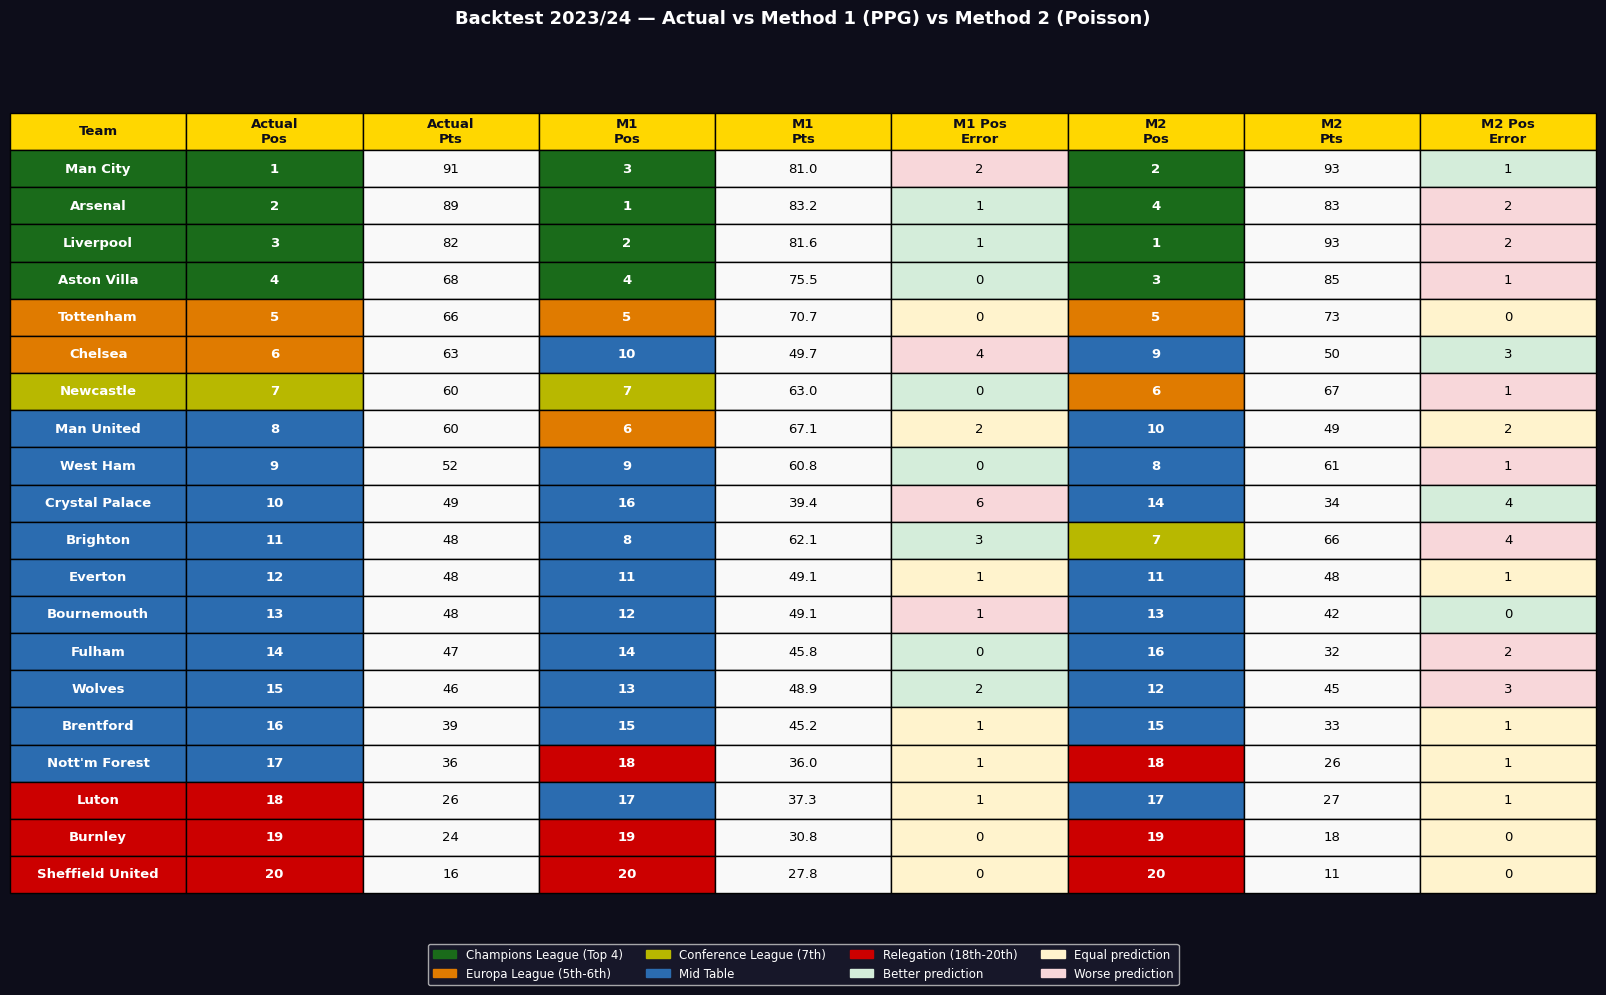

✅ Saved to Google Drive as pl_backtest_table.png


In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Build combined comparison ──
bt_viz = m1_comparison[['team', 'predicted_points', 'predicted_pos',
                          'actual_pos', 'actual_points', 'pos_error', 'pts_error']].copy()
bt_viz = bt_viz.rename(columns={
    'predicted_points': 'm1_points',
    'predicted_pos':    'm1_pos',
    'pts_error':        'm1_pts_error',
    'pos_error':        'm1_pos_error'
})

m2_viz = m2_comparison[['team', 'predicted_points', 'predicted_pos', 'pos_error', 'points_error']].copy()
m2_viz.columns = ['team', 'm2_points', 'm2_pos', 'm2_pos_error', 'm2_pts_error']

bt_viz = bt_viz.merge(m2_viz, on='team')
bt_viz = bt_viz.sort_values('actual_pos').reset_index(drop=True)

bt_viz['m1_pos_error'] = bt_viz['m1_pos_error'].fillna(0).astype(int)
bt_viz['m2_pos_error'] = bt_viz['m2_pos_error'].fillna(0).astype(int)

# ── Zone colors ──
def zone_color(pos):
    if pos <= 4:    return '#1a6b1a'
    elif pos <= 6:  return '#e07b00'
    elif pos == 7:  return '#b8b800'
    elif pos >= 18: return '#cc0000'
    else:           return '#2b6cb0'

# ── Build table rows and cell colors ──
columns = [
    'Team', 'Actual\nPos', 'Actual\nPts',
    'M1\nPos', 'M1\nPts', 'M1 Pos\nError',
    'M2\nPos', 'M2\nPts', 'M2 Pos\nError',
]
rows        = []
cell_colors = []

for _, row in bt_viz.iterrows():
    act_pos = int(row['actual_pos'])
    m1_pos  = int(row['m1_pos'])
    m2_pos  = int(row['m2_pos'])
    m1_err  = int(row['m1_pos_error'])
    m2_err  = int(row['m2_pos_error'])

    rows.append([
        row['team'], act_pos, int(row['actual_points']),
        m1_pos, round(row['m1_points'], 1), m1_err,
        m2_pos, round(row['m2_points'], 1), m2_err,
    ])

    actual_col = zone_color(act_pos)
    m1_col     = zone_color(m1_pos)
    m2_col     = zone_color(m2_pos)

    if m1_err < m2_err:
        m1_err_col, m2_err_col = '#d4edda', '#f8d7da'
    elif m2_err < m1_err:
        m1_err_col, m2_err_col = '#f8d7da', '#d4edda'
    else:
        m1_err_col, m2_err_col = '#fff3cd', '#fff3cd'

    cell_colors.append([
        actual_col, actual_col, '#f9f9f9',
        m1_col,     '#f9f9f9',  m1_err_col,
        m2_col,     '#f9f9f9',  m2_err_col,
    ])

# ── Figure: single panel, table only ──
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#0d0d1a')
ax.axis('off')
ax.set_facecolor('#0d0d1a')

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.2, 1.9)

# Header
for j in range(len(columns)):
    table[0, j].set_facecolor('#FFD700')
    table[0, j].set_text_props(color='#0d0d1a', fontweight='bold')

# White text on zone colored cells
for i in range(1, len(rows) + 1):
    for j in [0, 1, 3, 6]:
        table[i, j].set_text_props(color='white', fontweight='bold')

# ── Legend ──
legend_elements = [
    mpatches.Patch(color='#1a6b1a', label='Champions League (Top 4)'),
    mpatches.Patch(color='#e07b00', label='Europa League (5th-6th)'),
    mpatches.Patch(color='#b8b800', label='Conference League (7th)'),
    mpatches.Patch(color='#2b6cb0', label='Mid Table'),
    mpatches.Patch(color='#cc0000', label='Relegation (18th-20th)'),
    mpatches.Patch(color='#d4edda', label='Better prediction'),
    mpatches.Patch(color='#fff3cd', label='Equal prediction'),
    mpatches.Patch(color='#f8d7da', label='Worse prediction'),
]
ax.legend(handles=legend_elements, loc='lower center',
          bbox_to_anchor=(0.5, -0.04), ncol=4, fontsize=8.5,
          frameon=True, facecolor='#1a1a2e', labelcolor='white')

plt.title('Backtest 2023/24 — Actual vs Method 1 (PPG) vs Method 2 (Poisson)',
          fontsize=13, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pl_backtest_table.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("✅ Saved to Google Drive as pl_backtest_table.png")

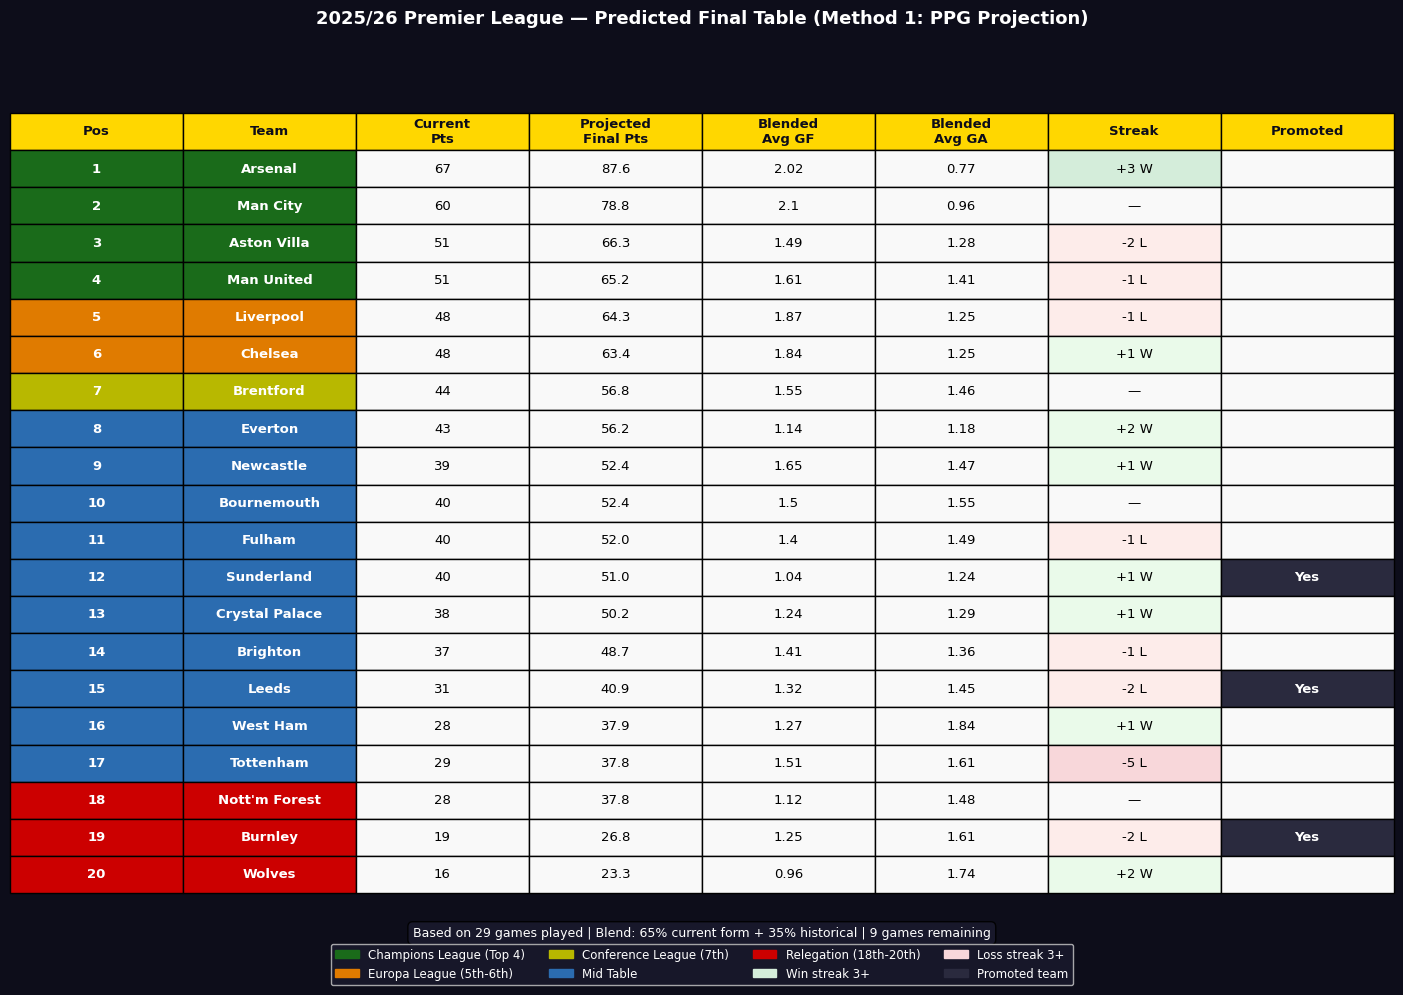

✅ Saved to Google Drive as pl_m1_predicted_table.png


In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Build Method 1 predicted table viz ──
m1_viz = master[['team', 'current_points', 'projected_points', 'blended_GF',
                  'blended_GA', 'streak', 'is_promoted']].copy()
m1_viz['projected_points'] = m1_viz['projected_points'].round(1)
m1_viz['blended_GF']       = m1_viz['blended_GF'].round(2)
m1_viz['blended_GA']       = m1_viz['blended_GA'].round(2)
m1_viz['projected_GD']     = ((m1_viz['blended_GF'] - m1_viz['blended_GA']) * 38).round(1)
m1_viz = m1_viz.sort_values(['projected_points', 'projected_GD'],
                              ascending=False).reset_index(drop=True)
m1_viz.index += 1
m1_viz.index.name = 'Position'

# ── Zone colors ──
def zone_color(pos):
    if pos <= 4:    return '#1a6b1a'
    elif pos <= 6:  return '#e07b00'
    elif pos == 7:  return '#b8b800'
    elif pos >= 18: return '#cc0000'
    else:           return '#2b6cb0'

def streak_str(s):
    s = int(s)
    if s > 0:   return f"+{s} W"
    elif s < 0: return f"{s} L"
    else:       return "—"

def streak_color(s):
    s = int(s)
    if s >= 3:    return '#d4edda'
    elif s > 0:   return '#eafaea'
    elif s <= -3: return '#f8d7da'
    elif s < 0:   return '#fdecea'
    else:         return '#f9f9f9'

# ── Build rows and colors ──
columns = [
    'Pos', 'Team', 'Current\nPts', 'Projected\nFinal Pts',
    'Blended\nAvg GF', 'Blended\nAvg GA', 'Streak', 'Promoted'
]
rows        = []
cell_colors = []

for pos, row in m1_viz.iterrows():
    promoted_str = 'Yes' if row['is_promoted'] == 1 else ''
    rows.append([
        pos,
        row['team'],
        int(row['current_points']),
        row['projected_points'],
        row['blended_GF'],
        row['blended_GA'],
        streak_str(row['streak']),
        promoted_str,
    ])

    base        = zone_color(pos)
    streak_col  = streak_color(row['streak'])
    promoted_col = '#2a2a3e' if row['is_promoted'] == 1 else '#f9f9f9'

    cell_colors.append([
        base,        # pos
        base,        # team
        '#f9f9f9',   # current pts
        '#f9f9f9',   # projected pts
        '#f9f9f9',   # blended GF
        '#f9f9f9',   # blended GA
        streak_col,  # streak
        promoted_col # promoted
    ])

# ── Plot ──
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0d0d1a')
ax.axis('off')
ax.set_facecolor('#0d0d1a')

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.2, 1.9)

# Header
for j in range(len(columns)):
    table[0, j].set_facecolor('#FFD700')
    table[0, j].set_text_props(color='#0d0d1a', fontweight='bold')

# White text on zone colored cells
for i in range(1, len(rows) + 1):
    table[i, 0].set_text_props(color='white', fontweight='bold')
    table[i, 1].set_text_props(color='white', fontweight='bold')
    # Promoted cell white text
    if rows[i-1][7] == 'Yes':
        table[i, 7].set_text_props(color='white', fontweight='bold')

# Zone divider lines
for boundary, label, color in [
    (4.5,  'Champions League cutoff', '#1a6b1a'),
    (6.5,  'Europa League cutoff',    '#e07b00'),
    (7.5,  'Conference cutoff',       '#b8b800'),
    (17.5, 'Relegation cutoff',       '#cc0000'),
]:
    # Draw a thick left border on the boundary row
    for j in range(len(columns)):
        if i == int(boundary) + 1:
            table[int(boundary) + 1, j].set_edgecolor(color)

# ── Legend ──
legend_elements = [
    mpatches.Patch(color='#1a6b1a', label='Champions League (Top 4)'),
    mpatches.Patch(color='#e07b00', label='Europa League (5th-6th)'),
    mpatches.Patch(color='#b8b800', label='Conference League (7th)'),
    mpatches.Patch(color='#2b6cb0', label='Mid Table'),
    mpatches.Patch(color='#cc0000', label='Relegation (18th-20th)'),
    mpatches.Patch(color='#d4edda', label='Win streak 3+'),
    mpatches.Patch(color='#f8d7da', label='Loss streak 3+'),
    mpatches.Patch(color='#2a2a3e', label='Promoted team'),
]
ax.legend(handles=legend_elements, loc='lower center',
          bbox_to_anchor=(0.5, -0.04), ncol=4, fontsize=8.5,
          frameon=True, facecolor='#1a1a2e', labelcolor='white')

# ── Summary banner ──
ax.text(0.5, 0.02,
    f"Based on {int(master['games'].mean())} games played | "
    f"Blend: {CURRENT_WEIGHT*100:.0f}% current form + {HIST_WEIGHT*100:.0f}% historical | "
    f"{38 - int(master['games'].mean())} games remaining",
    transform=ax.transAxes, ha='center', fontsize=9, color='white',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2e', alpha=0.9)
)

plt.title('2025/26 Premier League — Predicted Final Table (Method 1: PPG Projection)',
          fontsize=13, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pl_m1_predicted_table.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("✅ Saved to Google Drive as pl_m1_predicted_table.png")

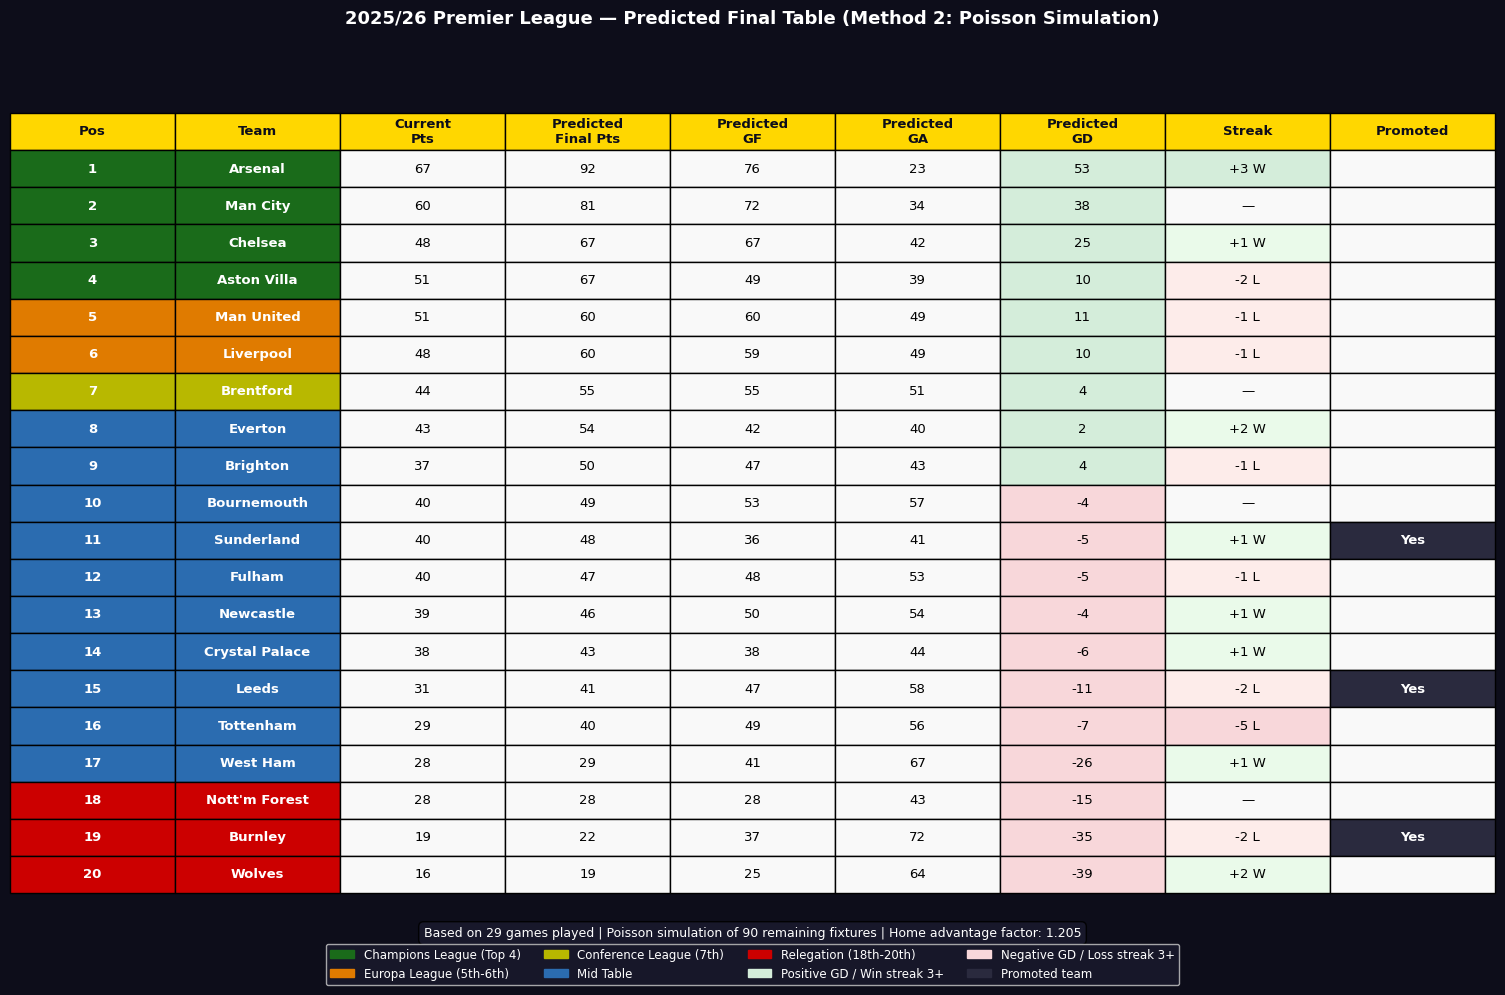

✅ Saved to Google Drive as pl_m2_predicted_table.png


In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Build Method 2 predicted table viz ──
m2_table_viz = final_table.copy()
m2_table_viz = m2_table_viz.reset_index(drop=True)
m2_table_viz.index += 1
m2_table_viz.index.name = 'Position'

# Add current points and streak from master
m2_table_viz = m2_table_viz.merge(
    master[['team', 'current_points', 'streak', 'is_promoted',
            'blended_GF', 'blended_GA']], on='team'
)
m2_table_viz = m2_table_viz.sort_values('points', ascending=False).reset_index(drop=True)
m2_table_viz.index += 1
m2_table_viz.index.name = 'Position'

# ── Zone colors ──
def zone_color(pos):
    if pos <= 4:    return '#1a6b1a'
    elif pos <= 6:  return '#e07b00'
    elif pos == 7:  return '#b8b800'
    elif pos >= 18: return '#cc0000'
    else:           return '#2b6cb0'

def streak_str(s):
    s = int(s)
    if s > 0:   return f"+{s} W"
    elif s < 0: return f"{s} L"
    else:       return "—"

def streak_color(s):
    s = int(s)
    if s >= 3:    return '#d4edda'
    elif s > 0:   return '#eafaea'
    elif s <= -3: return '#f8d7da'
    elif s < 0:   return '#fdecea'
    else:         return '#f9f9f9'

# ── Build rows and colors ──
columns = [
    'Pos', 'Team', 'Current\nPts', 'Predicted\nFinal Pts',
    'Predicted\nGF', 'Predicted\nGA', 'Predicted\nGD',
    'Streak', 'Promoted'
]
rows        = []
cell_colors = []

for pos, row in m2_table_viz.iterrows():
    promoted_str = 'Yes' if row['is_promoted'] == 1 else ''
    pred_GD      = round(row['GD'], 1) if 'GD' in row else '—'

    rows.append([
        pos,
        row['team'],
        int(row['current_points']),
        int(row['points']),
        round(row['GF'], 1),
        round(row['GA'], 1),
        pred_GD,
        streak_str(row['streak']),
        promoted_str,
    ])

    base         = zone_color(pos)
    streak_col   = streak_color(row['streak'])
    promoted_col = '#2a2a3e' if row['is_promoted'] == 1 else '#f9f9f9'

    # GD color — positive green, negative red
    if isinstance(pred_GD, float) or isinstance(pred_GD, int):
        gd_col = '#d4edda' if pred_GD > 0 else ('#f8d7da' if pred_GD < 0 else '#f9f9f9')
    else:
        gd_col = '#f9f9f9'

    cell_colors.append([
        base,         # pos
        base,         # team
        '#f9f9f9',    # current pts
        '#f9f9f9',    # predicted pts
        '#f9f9f9',    # predicted GF
        '#f9f9f9',    # predicted GA
        gd_col,       # predicted GD
        streak_col,   # streak
        promoted_col, # promoted
    ])

# ── Plot ──
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('#0d0d1a')
ax.axis('off')
ax.set_facecolor('#0d0d1a')

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.2, 1.9)

# Header
for j in range(len(columns)):
    table[0, j].set_facecolor('#FFD700')
    table[0, j].set_text_props(color='#0d0d1a', fontweight='bold')

# White text on zone colored cells
for i in range(1, len(rows) + 1):
    table[i, 0].set_text_props(color='white', fontweight='bold')
    table[i, 1].set_text_props(color='white', fontweight='bold')
    if rows[i-1][8] == 'Yes':
        table[i, 8].set_text_props(color='white', fontweight='bold')

# ── Legend ──
legend_elements = [
    mpatches.Patch(color='#1a6b1a', label='Champions League (Top 4)'),
    mpatches.Patch(color='#e07b00', label='Europa League (5th-6th)'),
    mpatches.Patch(color='#b8b800', label='Conference League (7th)'),
    mpatches.Patch(color='#2b6cb0', label='Mid Table'),
    mpatches.Patch(color='#cc0000', label='Relegation (18th-20th)'),
    mpatches.Patch(color='#d4edda', label='Positive GD / Win streak 3+'),
    mpatches.Patch(color='#f8d7da', label='Negative GD / Loss streak 3+'),
    mpatches.Patch(color='#2a2a3e', label='Promoted team'),
]
ax.legend(handles=legend_elements, loc='lower center',
          bbox_to_anchor=(0.5, -0.04), ncol=4, fontsize=8.5,
          frameon=True, facecolor='#1a1a2e', labelcolor='white')

# ── Summary banner ──
ax.text(0.5, 0.02,
    f"Based on {int(master['games'].mean())} games played | "
    f"Poisson simulation of {len(remaining_df)} remaining fixtures | "
    f"Home advantage factor: {home_advantage:.3f}",
    transform=ax.transAxes, ha='center', fontsize=9, color='white',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2e', alpha=0.9)
)

plt.title('2025/26 Premier League — Predicted Final Table (Method 2: Poisson Simulation)',
          fontsize=13, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pl_m2_predicted_table.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("✅ Saved to Google Drive as pl_m2_predicted_table.png")